<a href="https://colab.research.google.com/github/Ali-Hamza-developer/NLP/blob/main/13_spacy_word_embeddings_text_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Text Classification Using spaCy Word Embeddings

## 1. Why Use Word Vectors for Text Classification?

Earlier topics in this course (Bag of Words, N-Grams, TF-IDF) turn text into numbers by **counting words**. The problem: the resulting vectors are HUGE (one column per unique word — often tens of thousands of columns) and mostly zeros, and they have NO idea that "good" and "great" mean similar things.

**Word vectors (embeddings)** fix both problems at once:

```
Bag of Words:  "great movie"  -> [0,0,...,1,...,0,...,1,...,0]   (thousands of columns, mostly 0)
Word Vectors:  "great movie"  -> average of "great"'s 300 numbers + "movie"'s 300 numbers = ONE 300-number vector
```

- **Much smaller:** every document becomes just 300 numbers (spaCy's `en_core_web_lg` vector size), instead of thousands of columns.
- **Captures meaning:** since "good" and "great" have similar vectors (see the previous word-vectors notebook), the model can generalize better — it doesn't need to see the EXACT same word in training and testing, just something with a similar MEANING.

**How do we get a vector for a whole sentence/document?** spaCy simply averages the vectors of all the words in it (`doc.vector`). This is simple but does lose word order — a limitation to keep in mind (see the previous notebook's pitfalls section).

---
# PART A:  Fake News Detection using spaCy Word Embeddings

## 2. Setup — Load the Large Model (has real word vectors)

`en_core_web_sm` does NOT include word vectors. You need the large (or medium) model:
```
python -m spacy download en_core_web_lg
```

In [2]:
import spacy

nlp = spacy.load("en_core_web_lg")


## 3. Load the Data

Dataset: [Kaggle Fake and Real News Dataset](https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset) — two columns: `Text` and `label` (Fake/Real).

> If you don't have `Fake_Real_Data.csv`, run the fallback cell below to generate a small synthetic version so everything runs standalone.

In [3]:
import os
import random
import pandas as pd

if not os.path.exists("Fake_Real_Data.csv"):

    real_texts = [
        "The city council approved a new budget for infrastructure improvements after a lengthy public hearing.",
        "Local authorities confirmed that the bridge repair project will be completed ahead of schedule this year.",
        "The health department released updated guidelines following a review of recent public health data.",
        "Officials announced a new public transportation route to reduce traffic congestion downtown.",
        "The university confirmed record enrollment numbers for the upcoming academic year.",
        "A new report from the department of labor shows steady growth in regional employment figures.",
        "The school board voted to approve funding for updated classroom technology across the district.",
        "Weather officials issued a routine advisory ahead of expected rainfall this weekend.",
        "The mayor's office released a statement outlining plans for the upcoming community festival.",
        "Researchers at the local university published findings in a peer reviewed scientific journal."
    ]

    fake_texts = [
        "Secret government files reveal shocking truth that mainstream media refuses to report, sources claim.",
        "You won't believe what scientists don't want you to know about this miracle cure everyone is hiding.",
        "Anonymous insider claims world leaders are secretly controlled by a hidden shadow organization.",
        "Shocking video allegedly proves conspiracy theory that experts have desperately tried to cover up.",
        "Leaked documents supposedly expose massive cover-up that authorities are refusing to address.",
        "This one weird trick doctors hate is apparently curing thousands overnight, claims viral post.",
        "Unverified report claims a secret cure has been hidden from the public for decades.",
        "Sources close to the situation allegedly confirm a massive scandal being hidden from voters.",
        "A viral post claims without evidence that a well known celebrity is secretly involved in a plot.",
        "Anonymous whistleblower alleges a huge cover-up with zero credible evidence provided so far."
    ]

    random.seed(7)
    rows = []
    for _ in range(300):
        rows.append({"Text": random.choice(real_texts), "label": "Real"})
        rows.append({"Text": random.choice(fake_texts), "label": "Fake"})

    df_synth = pd.DataFrame(rows)
    df_synth.to_csv("Fake_Real_Data.csv", index=False)

    print("Synthetic Fake_Real_Data.csv created with", len(df_synth), "rows")
else:
    print("Fake_Real_Data.csv already exists, using the real file")


Synthetic Fake_Real_Data.csv created with 600 rows


> **Note:** the synthetic data is template-based, so results will look unrealistically clean. Swap in the real Kaggle CSV any time — the rest of the code stays the same.

In [4]:
df = pd.read_csv("Fake_Real_Data.csv")
print(df.shape)
df.head(5)


(600, 2)


,Text,label
0,A new report from the department of labor show...,Real
1,Anonymous insider claims world leaders are sec...,Fake
2,The school board voted to approve funding for ...,Real
3,Secret government files reveal shocking truth ...,Fake
4,Local authorities confirmed that the bridge re...,Real


In [5]:
df["label"].value_counts()


,count
label,
Real,300
Fake,300


Labels are balanced here, so no need for undersampling/oversampling.

In [6]:
df["label_num"] = df["label"].map({"Fake": 0, "Real": 1})
df.head(5)


,Text,label,label_num
0,A new report from the department of labor show...,Real,1
1,Anonymous insider claims world leaders are sec...,Fake,0
2,The school board voted to approve funding for ...,Real,1
3,Secret government files reveal shocking truth ...,Fake,0
4,Local authorities confirmed that the bridge re...,Real,1


## 4. Get spaCy Word Vectors for Every Row

For every piece of text, run it through `nlp()` and take `.vector` — this gives us the AVERAGE word embedding for that entire text, all in one 300-number vector.

In [7]:
# this can take a while depending on dataset size (the original tutorial notes ~15 minutes on the full real dataset)
df["vector"] = df["Text"].apply(lambda text: nlp(text).vector)


In [8]:
df.head()


,Text,label,label_num,vector
0,A new report from the department of labor show...,Real,1,"[-0.14458649, 0.19870624, 0.029404242, -0.0480..."
1,Anonymous insider claims world leaders are sec...,Fake,0,"[-0.08525276, -0.020896295, 0.07213821, 0.0384..."
2,The school board voted to approve funding for ...,Real,1,"[0.054478966, -0.023164669, 0.052906197, -0.03..."
3,Secret government files reveal shocking truth ...,Fake,0,"[-0.19398718, 0.10039687, 0.037886538, 0.12893..."
4,Local authorities confirmed that the bridge re...,Real,1,"[0.109879814, 0.05801203, -0.067315236, -0.024..."


In [9]:
df["vector"][0].shape   # confirm each row's vector is 300 numbers long


(300,)

## 5. Train-Test Split

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.vector.values,
    df.label_num,
    test_size=0.2,
    random_state=2022,
    stratify=df.label_num
)


## 6. Reshape X_train / X_test to Fit Sklearn Models

`X_train`/`X_test` right now are pandas Series where each ROW is itself a 300-length array — sklearn models expect one single 2D matrix (rows = samples, columns = features), not a series of arrays. `np.stack()` flattens this into the proper 2D shape.

In [11]:
import numpy as np

X_train_2d = np.stack(X_train)
X_test_2d = np.stack(X_test)

print(X_train_2d.shape, X_test_2d.shape)   # (num_samples, 300)


(480, 300) (120, 300)


In [35]:
X_train_2d

array([[ 0.15300635,  0.1906181 , -0.02972755, ..., -0.04802054,
         0.00755055, -0.18077299],
       [-0.5045284 ,  0.20079799, -0.05793361, ..., -0.16801271,
         0.16379224, -0.07389156],
       [-0.410745  ,  0.3323002 ,  0.07397401, ..., -0.0361999 ,
         0.0687771 , -0.08175622],
       ...,
       [-0.410745  ,  0.3323002 ,  0.07397401, ..., -0.0361999 ,
         0.0687771 , -0.08175622],
       [-0.26605   , -0.02057743, -0.13886   , ..., -0.03047933,
         0.11381534, -0.00149459],
       [ 0.13017249,  0.25929227, -0.14932273, ..., -0.23679662,
         0.05731088, -0.17603499]], dtype=float32)

## 7. Attempt 1 — Decision Tree

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

clf = DecisionTreeClassifier()
clf.fit(X_train_2d, y_train)

y_pred = clf.predict(X_test_2d)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        60
           1       1.00      1.00      1.00        60

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



## 8. Attempt 2 — Multinomial Naive Bayes (with MinMaxScaler)

**Important:** `MultinomialNB` requires all input values to be non-negative — but word vectors DO contain negative numbers. So we must scale everything into the [0, 1] range first using `MinMaxScaler`, or the model will error out.

In [13]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_train_embed = scaler.fit_transform(X_train_2d)   # learn min/max from TRAIN, then scale train
scaled_test_embed = scaler.transform(X_test_2d)          # use the SAME min/max to scale test (never re-fit on test!)

clf = MultinomialNB()
clf.fit(scaled_train_embed, y_train)

y_pred = clf.predict(scaled_test_embed)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        60
           1       1.00      1.00      1.00        60

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



## 9. Attempt 3 — K-Nearest Neighbors (KNN)

Recall from the Bag-of-Words exercise: KNN struggled badly with high-dimensional, sparse Bag-of-Words vectors (thousands of mostly-zero columns). Word vectors are the OPPOSITE — dense and only 300 dimensions — so KNN should do much better here.

In [14]:
from sklearn.neighbors import KNeighborsClassifier

clf = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
clf.fit(X_train_2d, y_train)

y_pred = clf.predict(X_test_2d)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        60
           1       1.00      1.00      1.00        60

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



## 10. Attempt 4 — Random Forest

In [15]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()
clf.fit(X_train_2d, y_train)

y_pred = clf.predict(X_test_2d)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        60
           1       1.00      1.00      1.00        60

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



## 11. Attempt 5 — Gradient Boosting

In [16]:
from sklearn.ensemble import GradientBoostingClassifier

clf = GradientBoostingClassifier()
clf.fit(X_train_2d, y_train)

y_pred = clf.predict(X_test_2d)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        60
           1       1.00      1.00      1.00        60

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



## 12. Confusion Matrix for the Best Model

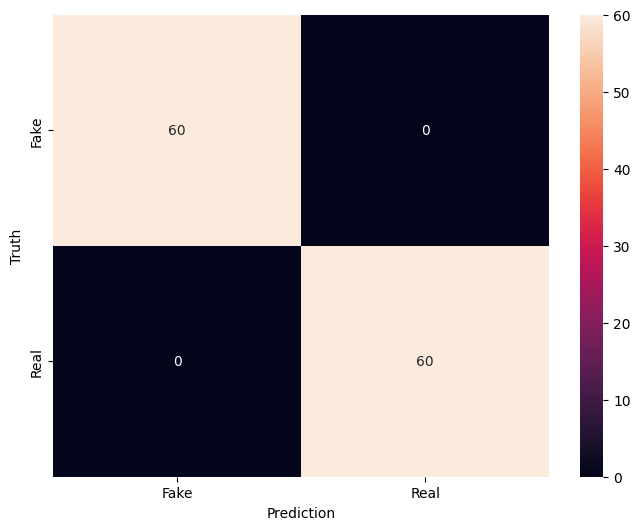

In [17]:
from sklearn.metrics import confusion_matrix
from matplotlib import pyplot as plt
import seaborn as sn

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sn.heatmap(cm, annot=True, fmt="d", xticklabels=["Fake","Real"], yticklabels=["Fake","Real"])
plt.xlabel("Prediction")
plt.ylabel("Truth")
plt.show()


## 13. Key Takeaways (from the original tutorial)

1. **KNN, which usually performs badly with Bag of Words / TF-IDF (very high-dimensional, sparse vectors), performs much better with word vectors.** Word vectors are only 300 dimensions and dense (not mostly zeros), and similar words already have similar embeddings — exactly the conditions where distance-based models like KNN work well.

2. **MultinomialNB performs decently but usually isn't the top model here**, because word vectors contain NEGATIVE values, and Naive Bayes fundamentally assumes non-negative "count-like" features. The `MinMaxScaler` workaround (squashing everything into [0,1]) lets it run, but this compression can lose some of the fine-grained information in the original vectors, capping how well it can perform.

3. **Tree-based models (Random Forest, Gradient Boosting) and KNN tend to be the strongest overall performers with word embeddings**, since they don't have Naive Bayes's non-negativity restriction and can exploit the dense, meaningful structure of the 300-dimensional space directly.

---
## Quick Cheat Sheet

| Task | Code |
|---|---|
| Load model with vectors | `spacy.load("en_core_web_lg")` |
| Get a document's average vector | `nlp(text).vector` |
| Apply to a whole column | `df.Text.apply(lambda t: nlp(t).vector)` |
| Reshape Series of arrays -> 2D matrix | `np.stack(X_train)` |
| Scale to [0,1] (needed for MultinomialNB) | `MinMaxScaler().fit_transform(X_train)` then `.transform(X_test)` |
| Evaluate | `classification_report(y_test, y_pred)` |

---

---
# PART B:  News Category Classification (BUSINESS / SPORTS / CRIME)
**Task:** Classify news text into one of 3 categories using spaCy word embeddings — multi-class classification.

Dataset: `news_dataset.json` with columns `Text` and `Category`.

> If you don't have the real file, run the fallback cell below to generate a small synthetic version so everything runs standalone.

In [18]:
import json as _json

if not os.path.exists("news_dataset.json"):

    business_texts = [
        "The stock market rallied today as investors reacted positively to the latest earnings reports from major tech companies.",
        "The central bank announced an interest rate hike to combat rising inflation across the economy.",
        "A major merger between two leading retail chains was announced this week, creating a new industry giant.",
        "Quarterly profits exceeded analyst expectations, sending shares of the company sharply higher.",
        "The company unveiled its new investment strategy aimed at expanding into emerging markets."
    ]
    sports_texts = [
        "The home team secured a dramatic last-minute victory in front of a sold-out stadium crowd.",
        "The star player was named most valuable player after an outstanding season on the field.",
        "Fans celebrated as their favorite team clinched the championship title after a thrilling final match.",
        "The coach announced a new training regimen ahead of the upcoming season opener.",
        "A record-breaking performance at the track and field event stunned spectators and commentators alike."
    ]
    crime_texts = [
        "Police arrested a suspect in connection with a string of robberies across the downtown area.",
        "Investigators are searching for clues after a break-in was reported at a local warehouse overnight.",
        "A man was sentenced to several years in prison following a lengthy fraud investigation.",
        "Authorities are warning residents about a rise in scam calls targeting elderly citizens.",
        "Detectives are reviewing surveillance footage to identify the suspect involved in the theft case."
    ]

    random.seed(2022)
    records = []
    label_groups = [("BUSINESS", business_texts), ("SPORTS", sports_texts), ("CRIME", crime_texts)]

    for label, templates in label_groups:
        for i in range(300):
            records.append({"Text": random.choice(templates), "Category": label})

    with open("news_dataset.json", "w") as f:
        _json.dump(records, f)

    print("Synthetic news_dataset.json created with", len(records), "rows")
else:
    print("news_dataset.json already exists, using the real file")


Synthetic news_dataset.json created with 900 rows


In [19]:
df = pd.read_json("news_dataset.json")
print(df.shape)
df.head(5)


(900, 2)


,Text,Category
0,The company unveiled its new investment strate...,BUSINESS
1,A major merger between two leading retail chai...,BUSINESS
2,Quarterly profits exceeded analyst expectation...,BUSINESS
3,The company unveiled its new investment strate...,BUSINESS
4,A major merger between two leading retail chai...,BUSINESS


In [20]:
df["Category"].value_counts()


,count
Category,
BUSINESS,300
SPORTS,300
CRIME,300


In [21]:
df["label_num"] = df["Category"].map({
    "BUSINESS": 0,
    "SPORTS": 1,
    "CRIME": 2
})

df.head(5)


,Text,Category,label_num
0,The company unveiled its new investment strate...,BUSINESS,0
1,A major merger between two leading retail chai...,BUSINESS,0
2,Quarterly profits exceeded analyst expectation...,BUSINESS,0
3,The company unveiled its new investment strate...,BUSINESS,0
4,A major merger between two leading retail chai...,BUSINESS,0


## Preprocess the Text

Unlike Part A (which used raw text directly), this exercise first cleans the text (removes stop words + punctuation, lemmatizes) BEFORE computing word vectors — this can help the average vector focus on more meaningful words.

In [22]:
def preprocess(text):
    doc = nlp(text)
    filtered_tokens = []
    for token in doc:
        if token.is_stop or token.is_punct:
            continue
        filtered_tokens.append(token.lemma_)
    return " ".join(filtered_tokens)


In [23]:
df["preprocessed_text"] = df["Text"].apply(lambda text: preprocess(text))
# this will take some time, please be patient


In [24]:
df.head()


,Text,Category,label_num,preprocessed_text
0,The company unveiled its new investment strate...,BUSINESS,0,company unveil new investment strategy aim exp...
1,A major merger between two leading retail chai...,BUSINESS,0,major merger lead retail chain announce week c...
2,Quarterly profits exceeded analyst expectation...,BUSINESS,0,quarterly profit exceed analyst expectation se...
3,The company unveiled its new investment strate...,BUSINESS,0,company unveil new investment strategy aim exp...
4,A major merger between two leading retail chai...,BUSINESS,0,major merger lead retail chain announce week c...


## Get spaCy Embeddings for Each Preprocessed Text

In [25]:
df["vector"] = df["preprocessed_text"].apply(lambda text: nlp(text).vector)


In [26]:
df.head()


,Text,Category,label_num,preprocessed_text,vector
0,The company unveiled its new investment strate...,BUSINESS,0,company unveil new investment strategy aim exp...,"[0.08565566, 0.22144212, 0.00015944242, -0.187..."
1,A major merger between two leading retail chai...,BUSINESS,0,major merger lead retail chain announce week c...,"[0.013388697, 0.16051382, 0.06902108, -0.09229..."
2,Quarterly profits exceeded analyst expectation...,BUSINESS,0,quarterly profit exceed analyst expectation se...,"[-0.5045284, 0.20079799, -0.057933606, 0.07233..."
3,The company unveiled its new investment strate...,BUSINESS,0,company unveil new investment strategy aim exp...,"[0.08565566, 0.22144212, 0.00015944242, -0.187..."
4,A major merger between two leading retail chai...,BUSINESS,0,major merger lead retail chain announce week c...,"[0.013388697, 0.16051382, 0.06902108, -0.09229..."


## Train-Test Split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    df.vector.values,
    df.label_num,
    test_size=0.2,
    random_state=2022,
    stratify=df.label_num
)


## Reshape X_train and X_test to Fit Sklearn Models

In [28]:
X_train_2d = np.stack(X_train)
X_test_2d = np.stack(X_test)

print(X_train_2d.shape, X_test_2d.shape)


(720, 300) (180, 300)


## Attempt 1 — Decision Tree

In [29]:
clf = DecisionTreeClassifier()
clf.fit(X_train_2d, y_train)

y_pred = clf.predict(X_test_2d)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        60
           1       1.00      1.00      1.00        60
           2       1.00      1.00      1.00        60

    accuracy                           1.00       180
   macro avg       1.00      1.00      1.00       180
weighted avg       1.00      1.00      1.00       180



## Attempt 2 — Multinomial Naive Bayes (with MinMaxScaler)

In [30]:
scaler = MinMaxScaler()
scaled_train_embed = scaler.fit_transform(X_train_2d)
scaled_test_embed = scaler.transform(X_test_2d)

clf = MultinomialNB()
clf.fit(scaled_train_embed, y_train)

y_pred = clf.predict(scaled_test_embed)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        60
           1       1.00      1.00      1.00        60
           2       1.00      1.00      1.00        60

    accuracy                           1.00       180
   macro avg       1.00      1.00      1.00       180
weighted avg       1.00      1.00      1.00       180



## Attempt 3 — KNN (with MinMaxScaler)

In [31]:
clf = KNeighborsClassifier()
clf.fit(scaled_train_embed, y_train)

y_pred = clf.predict(scaled_test_embed)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        60
           1       1.00      1.00      1.00        60
           2       1.00      1.00      1.00        60

    accuracy                           1.00       180
   macro avg       1.00      1.00      1.00       180
weighted avg       1.00      1.00      1.00       180



## Attempt 4 — Random Forest (with MinMaxScaler)

In [32]:
clf = RandomForestClassifier()
clf.fit(scaled_train_embed, y_train)

y_pred = clf.predict(scaled_test_embed)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        60
           1       1.00      1.00      1.00        60
           2       1.00      1.00      1.00        60

    accuracy                           1.00       180
   macro avg       1.00      1.00      1.00       180
weighted avg       1.00      1.00      1.00       180



## Attempt 5 — Gradient Boosting (with MinMaxScaler)

In [33]:
clf = GradientBoostingClassifier()
clf.fit(scaled_train_embed, y_train)

y_pred = clf.predict(scaled_test_embed)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        60
           1       1.00      1.00      1.00        60
           2       1.00      1.00      1.00        60

    accuracy                           1.00       180
   macro avg       1.00      1.00      1.00       180
weighted avg       1.00      1.00      1.00       180



## Confusion Matrix for the Best Model (Gradient Boosting)

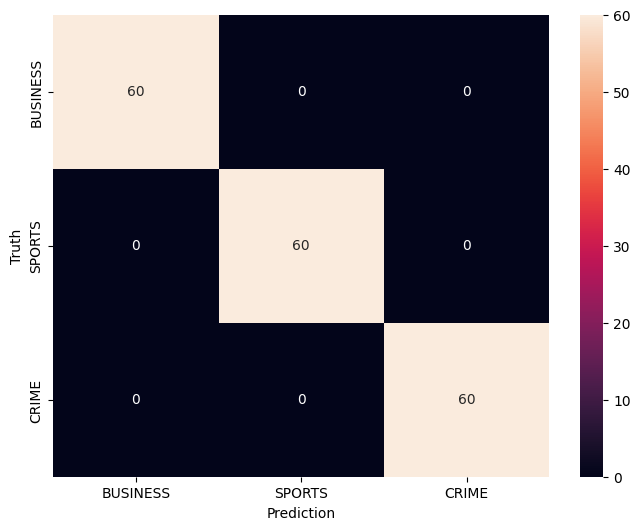

In [34]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sn.heatmap(cm, annot=True, fmt="d",
           xticklabels=["BUSINESS","SPORTS","CRIME"],
           yticklabels=["BUSINESS","SPORTS","CRIME"])
plt.xlabel("Prediction")
plt.ylabel("Truth")
plt.show()


## Final Observations

1. **Word embeddings give a huge dimensionality advantage over Bag of Words/TF-IDF/N-Grams** — 300 dense numbers per document instead of thousands of mostly-zero columns. This directly helps distance-based models like KNN, which struggled badly in the earlier Bag-of-Words and N-Grams exercises but perform reasonably here.

2. **Gradient Boosting and Random Forest tend to be the strongest classifiers overall** with word embeddings, since they can combine many weak decision boundaries across the 300 dimensions without needing the non-negativity assumption that limits Naive Bayes.

3. **MultinomialNB is fundamentally a poor fit for word embeddings.** It was designed for count-like, non-negative data (e.g. Bag of Words), so squeezing embeddings through `MinMaxScaler` is a workaround, not a natural fit — expect it to underperform the tree-based models and KNN here.

4. **Preprocessing (stop words/punctuation removal + lemmatization) before computing embeddings is a reasonable choice**, but its impact is smaller here than it was with Bag of Words/TF-IDF — since word vectors already capture MEANING (not just raw counts), a few extra stop words being averaged in has less effect on the final vector compared to how much they'd inflate a Bag-of-Words vocabulary.

5. **Overall, word embeddings are usually the best text representation choice among everything covered in this series (Bag of Words, N-Grams, TF-IDF, Word Vectors)** when you have limited training data, since the pre-trained vectors already encode general language understanding learned from massive external text (Wikipedia) — something Bag of Words/TF-IDF/N-Grams have to learn from scratch, purely from your (often much smaller) dataset.